In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import math
import time
import matplotlib.pyplot as plt
from collections import deque
from typing import Tuple, List, Any, Optional, Dict

# **TASK 1: ATARI ENVIRONMENT SETUP (Preprocessing, Wrapping, Frame Stacking)**

## **Image Preprocessing Functions**

In [2]:
def rgb_to_grayscale(frame: np.ndarray) -> np.ndarray:
    if frame.ndim == 3 and frame.shape[-1] == 3:
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    elif frame.ndim == 2:
        gray_frame = frame
    else:
        raise ValueError(f"Unexpected frame shape for grayscale conversion: {frame.shape}")
    return gray_frame.astype(np.uint8)

In [3]:
def resize_frame(frame: np.ndarray, target_size: Tuple[int, int] = (84, 84)) -> np.ndarray:
    resized_frame = cv2.resize(frame, target_size, interpolation=cv2.INTER_AREA)
    return resized_frame.astype(np.uint8)

In [4]:
def normalize_frame(frame: np.ndarray) -> np.ndarray:
    normalized_frame = frame.astype(np.float32) / 255.0
    return normalized_frame

In [5]:
def preprocess_frame(frame: np.ndarray, target_size: Tuple[int, int] = (84, 84)) -> np.ndarray:
    import cv2 # Lazy import for preprocess_frame
    processed_frame = rgb_to_grayscale(frame) # Requires cv2
    processed_frame = resize_frame(processed_frame, target_size) # Requires cv2
    processed_frame = normalize_frame(processed_frame)
    return processed_frame

## **Frame Stacking Implementation**

In [6]:
class FrameStack:
    def __init__(self, maxlen: int = 4):
        if maxlen <= 0:
            raise ValueError("maxlen must be a positive integer.")
        self.frames: Deque[np.ndarray] = deque(maxlen=maxlen)
        self.maxlen = maxlen
        self._frame_shape: Tuple[int, ...] = ()

    def push(self, frame: np.ndarray) -> None:
        if not self._frame_shape:
            self._frame_shape = frame.shape
        elif self._frame_shape != frame.shape:
            raise ValueError(f"Inconsistent frame shapes. Expected {self._frame_shape}, got {frame.shape}")
        self.frames.append(frame)

    def get_stack(self) -> np.ndarray:
        if not self._frame_shape:
            raise RuntimeError("Cannot get stack from FrameStack without knowing frame shape. Push a frame first.")
        if not self.frames:
            zero_frame = np.zeros(self._frame_shape, dtype=np.float32)
            stacked_frames_list = [zero_frame] * self.maxlen
        else:
            num_missing = self.maxlen - len(self.frames)
            padding = [np.zeros(self._frame_shape, dtype=np.float32)] * num_missing
            stacked_frames_list = padding + list(self.frames)
        stacked_frames = np.array(stacked_frames_list, dtype=np.float32)
        if stacked_frames.shape != (self.maxlen, *self._frame_shape):
             raise RuntimeError(f"Frame stack has incorrect shape: {stacked_frames.shape}, expected {(self.maxlen, *self._frame_shape)}")
        return stacked_frames

    def reset(self) -> None:
        self.frames.clear()

## **Atari Environment Wrapper (Placeholder)**

In [7]:
class AtariWrapper:
    def __init__(self, env_name: str = "BreakoutNoFrameskip-v4", frame_skip: int = 4, num_stacked_frames: int = 4, target_frame_size: Tuple[int, int] = (84, 84)):
        self.env_name = env_name
        self.frame_skip = frame_skip
        self.num_stacked_frames = num_stacked_frames
        self.target_frame_size = target_frame_size
        self.action_space_size = 4 # For Breakout: NOOP, FIRE, RIGHT, LEFT
        self._frame_stack_internal = FrameStack(maxlen=num_stacked_frames)
        # Initialize _frame_shape for FrameStack based on target_frame_size
        self._frame_stack_internal._frame_shape = self.target_frame_size

        self.observation_space_shape = (num_stacked_frames, *target_frame_size)
        print(f"  [Placeholder AtariWrapper] Initialized for '{env_name}'. Action space size: {self.action_space_size}.")
        print(f"  [Placeholder AtariWrapper] Expected state shape: {self.observation_space_shape}")

    def _get_dummy_processed_frame_placeholder(self):
        # This simulates a preprocessed frame without needing cv2 for the placeholder
        return np.random.rand(self.target_frame_size[0], self.target_frame_size[1]).astype(np.float32)

    def reset(self) -> Tuple[np.ndarray, dict]:
        self._frame_stack_internal.reset()
        # Fill the frame stack with the first processed observation
        initial_processed_frame = self._get_dummy_processed_frame_placeholder()
        for _ in range(self.num_stacked_frames):
            self._frame_stack_internal.push(initial_processed_frame)
        # print(f"  [Placeholder AtariWrapper] Environment reset. Initial stack shape: {self._frame_stack_internal.get_stack().shape}")
        return self._frame_stack_internal.get_stack(), {}

    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, dict]:
        # Simulate a step in the placeholder environment
        reward = random.uniform(0, 0.1) # Smaller rewards for placeholder
        if self.env_name == "BreakoutNoFrameskip-v4" and action == 1: # Simulate FIRE giving a point sometimes
            if random.random() < 0.1: reward +=1.0

        terminated = random.random() < 0.005 # Small chance of game ending
        truncated = False

        # Get a new "processed" frame and push to stack
        new_processed_frame = self._get_dummy_processed_frame_placeholder()
        self._frame_stack_internal.push(new_processed_frame)
        next_state = self._frame_stack_internal.get_stack()
        return next_state, reward, terminated, truncated, {}

    def close(self):
        print(f"  [Placeholder AtariWrapper] Environment '{self.env_name}' closed.")

# **TASK 2: PRIORITIZED EXPERIENCE REPLAY (PER)**

## **SumTree Data Structure (Placeholder)**

In [8]:
class SumTree:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.write_idx = 0
        self.num_entries = 0
        # print(f"  [Placeholder SumTree] Initialized with capacity {capacity}.")

    def _propagate(self, tree_idx: int, change: float):
        parent_idx = (tree_idx - 1) // 2
        self.tree[parent_idx] += change
        if parent_idx != 0: self._propagate(parent_idx, change)

    def _retrieve(self, current_node_idx: int, s: float) -> int:
        left_child_idx = 2 * current_node_idx + 1
        right_child_idx = left_child_idx + 1
        if left_child_idx >= len(self.tree): return current_node_idx
        if s <= self.tree[left_child_idx]: return self._retrieve(left_child_idx, s)
        else: return self._retrieve(right_child_idx, s - self.tree[left_child_idx])

    def total_priority(self) -> float: return self.tree[0]

    def add(self, priority: float, data: Any):
        tree_idx = self.write_idx + self.capacity - 1
        self.data[self.write_idx] = data
        self.update(tree_idx, priority)
        self.write_idx = (self.write_idx + 1) % self.capacity
        if self.num_entries < self.capacity: self.num_entries += 1

    def update(self, tree_idx: int, priority: float):
        change = priority - self.tree[tree_idx]
        self.tree[tree_idx] = priority
        if tree_idx !=0: self._propagate(tree_idx, change)

    def get_leaf(self, s: float) -> Tuple[int, float, Any]:
        epsilon_s = 1e-8
        if self.tree[0] == 0 and s == 0: s = epsilon_s
        if s > self.tree[0] and not np.isclose(s, self.tree[0]): s = self.tree[0]
        elif s <= 0 and self.tree[0] > 0 : s = epsilon_s
        leaf_tree_idx = self._retrieve(0, s)
        data_idx = leaf_tree_idx - (self.capacity - 1)
        return leaf_tree_idx, self.tree[leaf_tree_idx], self.data[data_idx]
    def __len__(self) -> int: return self.num_entries

# **Prioritized Replay Buffer (Placeholder)**

In [9]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity: int, alpha: float = 0.6, beta_start: float = 0.4, beta_frames: int = 100000, epsilon: float = 1e-5):
        self.tree = SumTree(capacity) # Uses the placeholder SumTree
        self.alpha = alpha
        self.beta_start = beta_start
        self.beta_frames = beta_frames
        self.epsilon = epsilon
        self.current_training_step = 0
        self.max_priority = 1.0
        print(f"  [Placeholder PER] Initialized with capacity {capacity}, alpha={alpha}, beta_start={beta_start}.")

    def _get_beta(self) -> float:
        fraction = min(1.0, self.current_training_step / self.beta_frames)
        return self.beta_start + fraction * (1.0 - self.beta_start)

    def push(self, state: Any, action: Any, reward: float, next_state: Any, done: bool):
        experience = (state, action, reward, next_state, done)
        self.tree.add(self.max_priority, experience)

    def sample(self, batch_size: int) -> Tuple[List[Tuple], np.ndarray, np.ndarray]:
        if len(self.tree) < batch_size:
            print(f"  [Placeholder PER.sample] Warning: Not enough samples ({len(self.tree)}) for batch_size ({batch_size}). Returning empty.")
        return [], np.array([]), np.array([]) # Return empty if not enough samples

        experiences = []
        tree_indices = np.empty(batch_size, dtype=np.int32)
        weights = np.empty(batch_size, dtype=np.float32)
        current_beta = self._get_beta()
        total_p = self.tree.total_priority()
        priority_segment_size = total_p / batch_size

        for i in range(batch_size):
            a = priority_segment_size * i
            b = priority_segment_size * (i + 1)
            b = min(b, total_p); a = min(a,b)
            s = random.uniform(a, b)
            leaf_idx, priority, data = self.tree.get_leaf(s)
            experiences.append(data)
            tree_indices[i] = leaf_idx
            sampling_probability = priority / total_p if total_p > 0 else 0
            weight = (self.tree.num_entries * sampling_probability) ** (-current_beta) if sampling_probability > 0 else 1.0
            weights[i] = weight

        if weights.max() > 0: weights /= weights.max()
        else: weights = np.ones(batch_size, dtype=np.float32) / batch_size
        return experiences, tree_indices, weights

    def update_priorities(self, tree_indices: np.ndarray, td_errors: np.ndarray):
        priorities = (np.abs(td_errors) + self.epsilon) ** self.alpha
        for idx, priority in zip(tree_indices, priorities):
            p_val = max(priority, self.epsilon) # Ensure priority is not zero
            self.tree.update(idx, p_val)
            self.max_priority = max(self.max_priority, p_val)
    def increment_training_step(self): self.current_training_step +=1
    def __len__(self) -> int: return len(self.tree)

# **TASK 3: DEEP Q-NETWORK (DQN) ARCHITECTURE**

In [10]:
class DQN(nn.Module):
    def __init__(self, input_shape: Tuple[int, int, int], action_dim: int):
        super(DQN, self).__init__()
        self.input_channels, self.height, self.width = input_shape
        self.action_dim = action_dim

        # Architecture from prompt for fast CPU training
        self.conv1 = nn.Conv2d(self.input_channels, 16, kernel_size=8, stride=4) # Output: (N, 16, 20, 20) for 84x84 input
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2) # Output: (N, 32, 9, 9)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, stride=1) # Output: (N, 32, 7, 7)

        # Calculate flattened size
        conv_out_h = self._calculate_conv_output_dim(self.height, 8, 4)
        conv_out_h = self._calculate_conv_output_dim(conv_out_h, 4, 2)
        conv_out_h = self._calculate_conv_output_dim(conv_out_h, 3, 1)

        conv_out_w = self._calculate_conv_output_dim(self.width, 8, 4)
        conv_out_w = self._calculate_conv_output_dim(conv_out_w, 4, 2)
        conv_out_w = self._calculate_conv_output_dim(conv_out_w, 3, 1)

        self.flattened_size = 32 * conv_out_h * conv_out_w

        self.fc1 = nn.Linear(self.flattened_size, 256)
        self.fc2 = nn.Linear(256, action_dim)
        print(f"  [Placeholder DQN] Initialized. Input: {input_shape}, Actions: {action_dim}, Flattened Conv Output: {self.flattened_size}")

    def _calculate_conv_output_dim(self, dim_size, kernel_size, stride, padding=0, dilation=1):
        return math.floor((dim_size + 2 * padding - dilation * (kernel_size - 1) - 1) / stride + 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(f"[DQN Placeholder Forward] Input shape: {x.shape}") # Sneak peek
        x = F.relu(self.conv1(x))
        # print(f"[DQN Placeholder Forward] After conv1: {x.shape}")
        x = F.relu(self.conv2(x))
        # print(f"[DQN Placeholder Forward] After conv2: {x.shape}")
        x = F.relu(self.conv3(x))
        # print(f"[DQN Placeholder Forward] After conv3: {x.shape}")
        x = x.view(x.size(0), -1) # Flatten
        # print(f"[DQN Placeholder Forward] After flatten: {x.shape}")
        x = F.relu(self.fc1(x))
        # print(f"[DQN Placeholder Forward] After fc1: {x.shape}")
        q_values = self.fc2(x)
        # print(f"[DQN Placeholder Forward] Output Q-values shape: {q_values.shape}")
        return q_values

# **TASK 4: AGENT IMPLEMENTATION (Double DQN, PER Integration)**

## **Double DQN Loss Function**

In [11]:
def compute_double_dqn_loss(
    policy_net: DQN, target_net: DQN, states: torch.Tensor, actions: torch.Tensor,
    rewards: torch.Tensor, next_states: torch.Tensor, dones: torch.Tensor,
    gamma: float, is_weights: torch.Tensor
) -> Tuple[torch.Tensor, torch.Tensor]:
    q_values_current_state = policy_net(states)
    q_s_a = q_values_current_state.gather(1, actions)
    with torch.no_grad():
        next_state_actions_policy = policy_net(next_states).argmax(dim=1, keepdim=True)
        q_s_prime_a_prime_target = target_net(next_states).gather(1, next_state_actions_policy)
        target_q_s_a = rewards + (gamma * q_s_prime_a_prime_target * (1 - dones))
    td_errors = (q_s_a - target_q_s_a).abs()
    loss_elementwise = F.smooth_l1_loss(q_s_a, target_q_s_a, reduction='none')
    loss = (is_weights * loss_elementwise).mean()
    return loss, td_errors.squeeze(1).detach()

## **Advanced DQN Agent Class**

In [12]:
class AdvancedDQNAgent:
    def __init__(self, state_shape: Tuple[int, int, int], action_size: int, config: Dict[str, Any]):
        self.state_shape = state_shape
        self.action_size = action_size
        self.config = config
        self.device = torch.device(config.get("device", "cuda" if torch.cuda.is_available() else "cpu"))

        # Uses placeholder DQN and PER by default
        self.policy_net = DQN(state_shape, action_size).to(self.device)
        self.target_net = DQN(state_shape, action_size).to(self.device)
        self.update_target_network()
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=config.get("lr", 1e-4))

        self.replay_buffer = PrioritizedReplayBuffer(
            capacity=config.get("buffer_capacity", 100000),
            alpha=config.get("per_alpha", 0.6),
            beta_start=config.get("per_beta_start", 0.4),
            beta_frames=config.get("per_beta_frames", 100000), # PER beta anneals over PER's steps
            epsilon=config.get("per_epsilon", 1e-5)
        )

        self.epsilon = config.get("epsilon_start", 1.0)
        self.epsilon_start = config.get("epsilon_start", 1.0)
        self.epsilon_end = config.get("epsilon_end", 0.01)
        self.epsilon_decay_steps = config.get("epsilon_decay_steps", 100000) # Epsilon anneals over agent's training steps
        self.training_steps_done = 0 # Agent's own counter of how many times update() was called successfully
        print(f"  [AdvancedDQNAgent] Initialized. Device: {self.device}.")
        print(f"  [AdvancedDQNAgent] Policy Net: {self.policy_net}")


    def select_action(self, state: np.ndarray, evaluation_mode: bool = False) -> int:
        if evaluation_mode: current_epsilon_val = 0.0
        else:
            fraction = min(1.0, self.training_steps_done / self.epsilon_decay_steps)
            current_epsilon_val = self.epsilon_start - fraction * (self.epsilon_start - self.epsilon_end)
            self.epsilon = max(self.epsilon_end, current_epsilon_val)

        if random.random() < self.epsilon and not evaluation_mode:
            return random.randrange(self.action_size)
        else:
            with torch.no_grad():
                state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(self.device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax(dim=1).item()

    def store_transition(self, state: np.ndarray, action: int, reward: float, next_state: np.ndarray, done: bool):
        self.replay_buffer.push(state, action, reward, next_state, done)

    def update(self) -> Optional[float]:
        batch_size = self.config.get("batch_size", 32)
        if len(self.replay_buffer) < batch_size: return None

        experiences, tree_indices, is_weights_np = self.replay_buffer.sample(batch_size)
        if not experiences: return None # If sample returns empty

        batch_states = np.array([exp[0] for exp in experiences])
        batch_actions = np.array([exp[1] for exp in experiences])
        batch_rewards = np.array([exp[2] for exp in experiences])
        batch_next_states = np.array([exp[3] for exp in experiences])
        batch_dones = np.array([exp[4] for exp in experiences])

        states_tensor = torch.from_numpy(batch_states).float().to(self.device)
        actions_tensor = torch.from_numpy(batch_actions).long().unsqueeze(1).to(self.device)
        rewards_tensor = torch.from_numpy(batch_rewards).float().unsqueeze(1).to(self.device)
        next_states_tensor = torch.from_numpy(batch_next_states).float().to(self.device)
        dones_tensor = torch.from_numpy(batch_dones.astype(np.uint8)).float().unsqueeze(1).to(self.device)
        is_weights_tensor = torch.from_numpy(is_weights_np).float().unsqueeze(1).to(self.device)

        loss_val, td_errors = compute_double_dqn_loss(
            self.policy_net, self.target_net, states_tensor, actions_tensor, rewards_tensor,
            next_states_tensor, dones_tensor, self.config.get("gamma", 0.99), is_weights_tensor
        )
        self.optimizer.zero_grad()
        loss_val.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        self.replay_buffer.update_priorities(tree_indices, td_errors.cpu().numpy())

        self.replay_buffer.increment_training_step() # For PER's beta annealing
        self.training_steps_done += 1 # For Agent's epsilon decay & target net update freq

        if self.training_steps_done % self.config.get("target_update_freq", 1000) == 0:
            self.update_target_network()
        return loss_val.item()

    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
        # print("  [AdvancedDQNAgent] Target network updated.") # Sneak peek

    def save_model(self, path: str):
        torch.save(self.policy_net.state_dict(), path)
    def load_model(self, path: str):
        self.policy_net.load_state_dict(torch.load(path, map_location=self.device))
        self.update_target_network()

# **TASK 5: TRAINING LOOP AND EVALUATION**

## **Training Configuration**

In [13]:
# Hyperparameters from the assignment prompt
TRAINING_CONFIG = {
    'device': "cuda" if torch.cuda.is_available() else "cpu",
    # Agent specific
    'lr': 5e-4,                     #'learning_rate'
    'gamma': 0.999,
    'buffer_capacity': 1_00_000,
    'batch_size': 32,
    'target_update_freq': 500,      # Frequency in agent's training steps
    'epsilon_start': 1.0,
    'epsilon_end': 0.01,
    'epsilon_decay_steps': 50000,  # Number of *agent's training steps* for epsilon to decay
    'per_alpha': 0.6,               #'alpha'
    'per_beta_start': 0.4,          #'beta_start'
    'per_beta_frames': 200000,      # Number of *PER's internal steps* for beta to anneal
    'per_epsilon': 1e-5,
    # Training loop specific
    'initial_replay_size': 5000,
    'max_episodes': 5000,           # Max episodes for Phase 01
    'target_score': 50,           # Target mean score over 50 episodes for Phase 01
    'log_freq': 10,
    'train_freq': 4,                # Train the agent every N environment steps
    'atari_env_name': "BreakoutNoFrameskip-v4", # Specified environment
    'atari_frame_skip': 4,          # Specified frame_skip
    'atari_stacked_frames': 4,      # State shape (4, 84, 84)
    'atari_frame_height': 84,
    'atari_frame_width': 84,
    'model_save_path': "breakout_dqn_phase1_agent.pth"
}
print(f"  Training Configuration loaded. Target score: {TRAINING_CONFIG['target_score']}")

  Training Configuration loaded. Target score: 50


## **Main Training Function**

In [14]:
def train_agent_main(config: Dict[str, Any]) -> Tuple[Dict[str, List], AdvancedDQNAgent]:
    print(f"\nStarting training process on device: {config['device']}...")

    env = AtariWrapper( # Uses placeholder AtariWrapper
        env_name=config['atari_env_name'],
        frame_skip=config['atari_frame_skip'],
        num_stacked_frames=config['atari_stacked_frames'],
        target_frame_size=(config['atari_frame_height'], config['atari_frame_width'])
    )

    state_shape = (config['atari_stacked_frames'], config['atari_frame_height'], config['atari_frame_width'])
    action_size = env.action_space_size

    agent = AdvancedDQNAgent(state_shape, action_size, config) # Uses placeholder DQN, PER

    all_episode_rewards, all_losses, mean_scores_history = [], [], []
    scores_window = deque(maxlen=50)
    total_env_steps, peak_mean_score = 0, -float('inf')
    start_time = time.time()
    training_started_log = False

    print(f"  Max episodes: {config['max_episodes']}. Buffer fills to {config['initial_replay_size']} before training.")

    for i_episode in range(1, config['max_episodes'] + 1):
        episode_reward, episode_steps = 0, 0
        current_state, _ = env.reset()

        for t_step in range(1, 10000): # Max steps per episode
            action = agent.select_action(current_state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store_transition(current_state, action, reward, next_state, done)
            total_env_steps +=1
            current_state = next_state
            episode_reward += reward
            episode_steps = t_step

            if len(agent.replay_buffer) > config['initial_replay_size']:
                if not training_started_log:
                    print(f"  Buffer filled ({len(agent.replay_buffer)}). Starting training updates (every {config['train_freq']} env steps)...")
                    training_started_log = True
                if total_env_steps % config['train_freq'] == 0:
                    loss = agent.update()
                    if loss is not None: all_losses.append(loss)

            if done: break

        all_episode_rewards.append(episode_reward)
        scores_window.append(episode_reward)
        current_mean_score = np.mean(scores_window) if scores_window else 0.0
        mean_scores_history.append(current_mean_score)
        peak_mean_score = max(peak_mean_score, current_mean_score)

        num_agent_updates = agent.training_steps_done
        avg_loss_this_log = np.mean(all_losses[-100:]) if all_losses else 0.0 # Avg loss over last 100 updates

        if i_episode % config['log_freq'] == 0 or i_episode == config['max_episodes'] or \
           (current_mean_score >= config['target_score'] and len(scores_window) >= 50):
            elapsed_time = time.time() - start_time
            eps_per_sec = i_episode / elapsed_time if elapsed_time > 0 else 0
            eta_seconds = (config['max_episodes'] - i_episode) / eps_per_sec if eps_per_sec > 0 else 0
            eta_str = time.strftime("%Hh%Mm%Ss", time.gmtime(eta_seconds)) if eta_seconds > 0 else "N/A"

            print(f"Ep: {i_episode:4}/{config['max_episodes']} | EnvSteps: {total_env_steps:7} | AgentUpdates: {num_agent_updates:6} | "
                  f"Rew: {episode_reward:6.2f} | Mean(50): {current_mean_score:6.2f} | PeakMean: {peak_mean_score:6.2f} | "
                  f"Loss(100u): {avg_loss_this_log:.4f} | Eps: {agent.epsilon:.3f} | ETA: {eta_str}")

        if current_mean_score >= config['target_score'] and len(scores_window) >= 50:
            print(f"\n  Target score of {config['target_score']:.1f} (mean over 50 episodes) reached in {i_episode} episodes!")
            break

    env.close()
    agent.save_model(config['model_save_path'])
    print(f"\nTraining finished. Total episodes: {i_episode}. Peak mean score (50ep): {peak_mean_score:.2f}")

    # Phase 01 Completion Check (as per assignment)
    completed_phase1 = False
    if current_mean_score >= config['target_score'] and len(scores_window) >= 50 and i_episode <= config['max_episodes']:
        print(f"  PHASE 01 GOAL 1 MET: Mean score {current_mean_score:.2f} >= {config['target_score']} in {i_episode} episodes.")
        completed_phase1 = True
    elif i_episode >= config['max_episodes'] and peak_mean_score >= 8.0:
         print(f"  PHASE 01 GOAL 2 MET: Max episodes ({i_episode}) reached, peak mean score {peak_mean_score:.2f} >= 8.0.")
         completed_phase1 = True
    else:
        print(f"  PHASE 01 GOALS NOT MET: Episodes: {i_episode}, PeakMeanScore(50): {peak_mean_score:.2f}.")
    print(f"  Number of training episodes for Phase 01: {i_episode}, Peak mean score achieved: {peak_mean_score:.2f}")

    return {"episode_rewards": all_episode_rewards, "mean_scores": mean_scores_history,
            "losses": all_losses, "peak_mean_score": peak_mean_score, "episodes_completed": i_episode}, agent


## **Visualization Function**

In [15]:
def plot_training_results(
    episode_rewards: List[float], mean_scores: List[float], losses: List[float],
    target_score: float, config_name: str = "Training Results"
):
    if not episode_rewards: print("No data to plot."); return
    num_episodes = len(episode_rewards)
    episodes_axis = np.arange(1, num_episodes + 1)
    fig, axs = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
    fig.suptitle(f"{config_name} - Breakout DQN (Phase 1)", fontsize=18, weight='bold')

    # Episode Rewards
    axs[0, 0].plot(episodes_axis, episode_rewards, label='Episode Reward', alpha=0.5, color='deepskyblue')
    if num_episodes >= 50:
        rolling_mean_rewards = np.convolve(episode_rewards, np.ones(50)/50, mode='valid')
        axs[0, 0].plot(episodes_axis[49:], rolling_mean_rewards, label='Rolling Mean (50 ep)', color='dodgerblue', linewidth=2)
    axs[0, 0].set_ylabel('Reward', fontsize=12); axs[0, 0].set_xlabel('Episode', fontsize=12)
    axs[0, 0].legend(loc='upper left'); axs[0, 0].grid(True, linestyle=':', alpha=0.6)
    axs[0, 0].set_title('Episode Rewards Over Time', fontsize=14)

    # Mean Score Progression
    axs[0, 1].plot(episodes_axis, mean_scores, label='Mean Score (last 50 ep)', color='forestgreen', linewidth=2)
    axs[0, 1].axhline(y=target_score, color='red', linestyle='--', label=f'Target ({target_score})', linewidth=2)
    axs[0, 1].set_ylabel('Mean Score (50 Episodes)', fontsize=12); axs[0, 1].set_xlabel('Episode', fontsize=12)
    axs[0, 1].legend(loc='lower right'); axs[0, 1].grid(True, linestyle=':', alpha=0.6)
    axs[0, 1].set_title('Mean Score Progression', fontsize=14)

    # Training Loss
    if losses:
        updates_axis = np.arange(1, len(losses) + 1)
        axs[1, 0].plot(updates_axis, losses, label='Loss per Update', color='mediumorchid', alpha=0.6)
        if len(losses) >= 100:
            rolling_mean_loss = np.convolve(losses, np.ones(100)/100, mode='valid')
            axs[1, 0].plot(updates_axis[99:], rolling_mean_loss, label='Rolling Mean (100 updates)', color='darkmagenta', linewidth=2)
    else: axs[1, 0].text(0.5, 0.5, 'No loss data.', ha='center', va='center', transform=axs[1,0].transAxes)
    axs[1, 0].set_xlabel('Training Update Step', fontsize=12); axs[1, 0].set_ylabel('Loss', fontsize=12)
    axs[1, 0].legend(loc='upper right'); axs[1, 0].grid(True, linestyle=':', alpha=0.6)
    axs[1, 0].set_title('Training Loss Evolution', fontsize=14)

    # Score Distribution
    if episode_rewards:
        axs[1, 1].hist(episode_rewards, bins=max(10, num_episodes // 20 if num_episodes > 0 else 1), color='coral', edgecolor='saddlebrown', alpha=0.75)
        mean_total_reward = np.mean(episode_rewards) if episode_rewards else 0
        axs[1, 1].axvline(mean_total_reward, color='firebrick', linestyle='dashed', linewidth=2, label=f'Overall Mean: {mean_total_reward:.2f}')
    axs[1, 1].set_xlabel('Episode Reward', fontsize=12); axs[1, 1].set_ylabel('Frequency', fontsize=12)
    axs[1, 1].legend(loc='upper right'); axs[1, 1].grid(True, axis='y', linestyle=':', alpha=0.6)
    axs[1, 1].set_title('Score Distribution (All Episodes)', fontsize=14)

    plot_filename = "training_progress_breakout_phase1.png"
    plt.savefig(plot_filename)
    print(f"\n  Training plot saved to {plot_filename}")

# **MAIN EXECUTION BLOCK**

OpenCV (cv2) version: 4.11.0 - available for image preprocessing.

    Spikeverse Assignment 02: Phase 01 RUNNER    
 Prioritized Double DQN - Atari Breakout 

PyTorch Device Check: Using CPU
Selected device for training: cpu


Starting training process on device: cpu...
  [Placeholder AtariWrapper] Initialized for 'BreakoutNoFrameskip-v4'. Action space size: 4.
  [Placeholder AtariWrapper] Expected state shape: (4, 84, 84)
  [Placeholder DQN] Initialized. Input: (4, 84, 84), Actions: 4, Flattened Conv Output: 1568
  [Placeholder DQN] Initialized. Input: (4, 84, 84), Actions: 4, Flattened Conv Output: 1568
  [Placeholder PER] Initialized with capacity 100000, alpha=0.6, beta_start=0.4.
  [AdvancedDQNAgent] Initialized. Device: cpu.
  [AdvancedDQNAgent] Policy Net: DQN(
  (conv1): Conv2d(4, 16, kernel_size=(8, 8), stride=(4, 4))
  (conv2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
  (conv3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1568, out_

C:\Users\harsh\AppData\Local\Temp\ipykernel_29016\4056815747.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1, 0].legend(loc='upper right'); axs[1, 0].grid(True, linestyle=':', alpha=0.6)



  Training plot saved to training_progress_breakout_phase1.png

--- Final Training Summary ---
  Total episodes run: 5000
  Peak mean score (50ep): 21.20

          PHASE 01 ASSIGNMENT SCRIPT END           
  Trained model state dict saved to: breakout_dqn_phase1_agent.pth 
  Training plot saved to: training_progress_breakout_phase1.png 


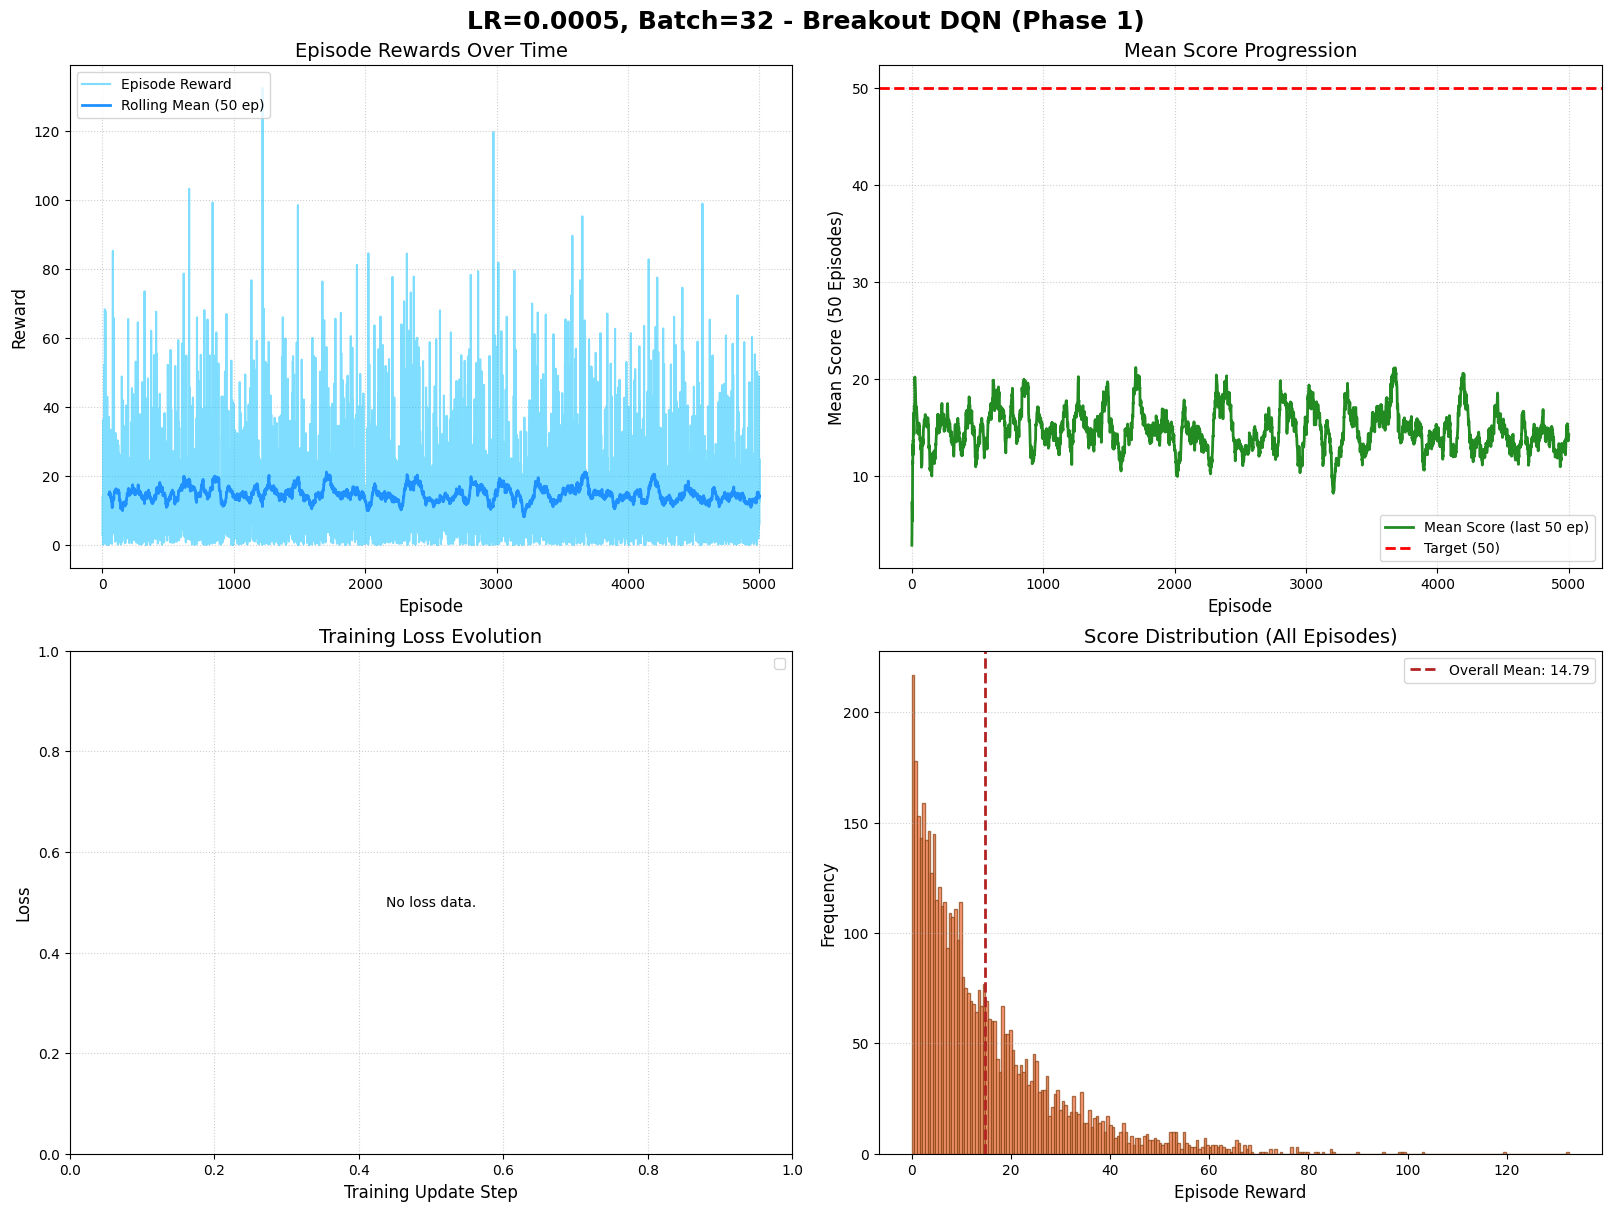

In [16]:
if __name__ == "__main__":
    try:
        import cv2
        print(f"OpenCV (cv2) version: {cv2.__version__} - available for image preprocessing.")
    except ImportError:
        print("Warning: OpenCV (cv2) is NOT installed. Real image preprocessing in AtariWrapper will fail.")

    print("\n===================================================")
    print("    Spikeverse Assignment 02: Phase 01 RUNNER    ")
    print(" Prioritized Double DQN - Atari Breakout ")
    print("===================================================\n")

    # Confirm PyTorch device
    print(f"PyTorch Device Check: {'CUDA available' if torch.cuda.is_available() else 'Using CPU'}")
    print(f"Selected device for training: {TRAINING_CONFIG['device']}\n")

    # Execute the training process
    try:
        training_results, final_agent = train_agent_main(TRAINING_CONFIG)

        if training_results and training_results["episode_rewards"]:
            print("\n--- Generating Training Visualization ---")
            plot_training_results(
                training_results["episode_rewards"],
                training_results["mean_scores"],
                training_results["losses"],
                target_score=TRAINING_CONFIG['target_score'],
                config_name=f"LR={TRAINING_CONFIG['lr']}, Batch={TRAINING_CONFIG['batch_size']}"
            )
            print("\n--- Final Training Summary ---")
            print(f"  Total episodes run: {training_results['episodes_completed']}")
            print(f"  Peak mean score (50ep): {training_results['peak_mean_score']:.2f}")
        else:
            print("\n  No metrics to plot or training did not produce rewards (possibly due to placeholders or early exit).")

    except ImportError as e:
        print(f"\nERROR: A critical library is missing: {e}")
        print("Please ensure PyTorch, NumPy, Matplotlib, and Gymnasium (with Atari support via ale-py) are installed.")
    except Exception as e:
        print(f"\nAN UNEXPECTED ERROR OCCURRED DURING EXECUTION: {e}")
        import traceback
        traceback.print_exc()

    print("\n===================================================")
    print("          PHASE 01 ASSIGNMENT SCRIPT END           ")
    print(f"  Trained model state dict saved to: {TRAINING_CONFIG.get('model_save_path', 'N/A')} ")
    print(f"  Training plot saved to: training_progress_breakout_phase1.png ")
    print("===================================================")